# 06 - Ticker sentiment (long/short lean, -1 .. +1)

Scores posts from the notebook-01 slice with VADER + a WSB lexicon, rolls
them up per ticker per day, charts each ticker's retail lean, and draws
the momentum map (JPM *Through The Retail Lens* style). Runs in <= 2 min:
parallel scoring on all cores, 300-char truncation, seeded sample cap.

**FAQ - read this before interpreting the charts:**

- **Why gaps in the lines?** Days with fewer than the masking floor of
  scored posts are deliberately blanked (a 3-post day is noise, not data).
  When sampling is on, the floor AUTO-SCALES down by the sample fraction -
  otherwise mid-size tickers would be masked almost everywhere. Fewer
  gaps: raise `MAX_SCORE_POSTS` (or None) or lower `MIN_POSTS`.
- **Why does everything look bullish?** Real level bias, not a bug:
  retail forums skew long, bullish slang outnumbers bearish, and lexicon
  scoring inherits that. LEVELS are therefore untrustworthy - the map's
  y-axis uses the CHANGE (last 5 days minus the ticker's own window
  average), which cancels the per-name bias. The monitor table carries
  both (`sent_5d` level and `sent_delta` change).
- **What does '5-day' mean on a year of data?** The map is a SNAPSHOT of
  the final 5 days of the window; the rest of the window is only the
  baseline the z-scores and deltas are measured against. The title shows
  the exact snapshot date. The full-year evolution lives in the
  per-ticker time charts (and notebook 08's heatmaps/snail trails).

Headline metric: `net_bullish` = bulls share - bears share, in [-1, +1].
Scores cached in `posts_slice_sentiment.parquet`, shared with notebook 07.

In [14]:
import os, sys
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, ROOT)
print('project root:', ROOT)

project root: c:\Users\alexd\Desktop\GIC\RetailFlow1


In [15]:
# ============ PARAMETERS - edit these ============
SLICE_PATH      = os.path.join(ROOT, 'data', 'processed', 'posts_slice.parquet')
SENTIMENT_CACHE = os.path.join(ROOT, 'data', 'processed', 'posts_slice_sentiment.parquet')
SENTIMENT_OUT   = os.path.join(ROOT, 'data', 'processed', 'daily_ticker_sentiment.parquet')
TICKERS         = []       # e.g. ['GME', 'NVDA']; [] = TOP_N most-posted tickers
TOP_N           = 6
MIN_POSTS       = 5        # masking floor at FULL scoring (auto-scales when sampling)
ROLL            = 7        # rolling window (days) for the sentiment lines
CASHTAGS_ONLY   = False    # True = attribute sentiment only via $TICKER posts
MAP_TICKERS     = 25       # how many tickers to label on the momentum map
MAX_SCORE_POSTS = 500_000  # scoring budget (seeded sample if slice is bigger); None = all
N_JOBS          = -1       # CPU cores for scoring; -1 = all of them
# ==================================================

In [16]:
# SCORE the posts - parallel + capped, cached for re-runs and notebook 07.
import pandas as pd
import importlib
import src.extract_tickers, src.sentiment
importlib.reload(src.extract_tickers)
importlib.reload(src.sentiment)
from src.sentiment import add_sentiment_fast

if not os.path.exists(SLICE_PATH):
    raise FileNotFoundError('posts_slice.parquet not found - run notebook 01 first.')

posts = pd.read_parquet(SLICE_PATH, columns=['date', 'title', 'selftext', 'score'])
WINDOW = f"{posts['date'].min()} to {posts['date'].max()}"
print(f'slice: {len(posts):,} posts | window: {WINDOW}')

expected_n = len(posts) if MAX_SCORE_POSTS is None else min(MAX_SCORE_POSTS, len(posts))
SAMPLE_FRAC = expected_n / len(posts)

# When sampling, scale the masking floor down too - a ticker with 20 real
# posts/day only gets ~20*frac scored, and the full-scoring floor would
# mask it everywhere (that is what caused 'gaps in the data').
MIN_POSTS_EFF = MIN_POSTS if SAMPLE_FRAC >= 1 else max(2, round(MIN_POSTS * SAMPLE_FRAC))
if SAMPLE_FRAC < 1:
    print(f'sampling {SAMPLE_FRAC:.0%} -> masking floor scaled {MIN_POSTS} -> {MIN_POSTS_EFF}')

scored = None
if os.path.exists(SENTIMENT_CACHE):
    scored = pd.read_parquet(SENTIMENT_CACHE)
    if len(scored) != expected_n:
        print('cache does not match this slice/budget - rescoring...')
        scored = None
    else:
        print('loaded cached sentiment scores')

if scored is None:
    to_score = posts
    if expected_n < len(posts):
        to_score = posts.sample(expected_n, random_state=0)
        print('=' * 66)
        print(f'SAMPLING: scoring {expected_n:,} of {len(posts):,} posts '
              f'({SAMPLE_FRAC:.0%}, seed=0). Post volumes below are SCORED\n'
              'posts (proportional to true volume); sentiment shares are\n'
              'estimates within ~1-2 points. MAX_SCORE_POSTS=None for exact.')
        print('=' * 66)
    import time; t0 = time.time()
    scored = add_sentiment_fast(to_score, n_jobs=N_JOBS)
    print(f'scored {len(scored):,} posts in {time.time() - t0:.0f}s')
    scored.to_parquet(SENTIMENT_CACHE, index=False)
    print('saved cache ->', SENTIMENT_CACHE)

scored['sentiment'].describe()

slice: 2,833,008 posts | window: 2021-01-01 to 2021-12-31
sampling 18% -> masking floor scaled 5 -> 2
loaded cached sentiment scores


count    500000.000000
mean          0.157853
std           0.401592
min          -0.999500
25%           0.000000
50%           0.000000
75%           0.458800
max           0.999900
Name: sentiment, dtype: float64

In [17]:
# Roll up per ticker per day (same extractor as notebook 02, so the
# word-ticker screening applies to sentiment attribution too).
from pathlib import Path
from src.sentiment import build_daily_ticker_sentiment
from src.ticker_universe import load_us_ticker_universe

universe = load_us_ticker_universe(Path(ROOT) / 'data' / 'reference', max_cache_age_days=365)

daily_sent = build_daily_ticker_sentiment(scored, universe, cashtags_only=CASHTAGS_ONLY)
daily_sent['date'] = pd.to_datetime(daily_sent['date'])
daily_sent.to_parquet(SENTIMENT_OUT, index=False)
print('rows:', len(daily_sent), '-> saved', SENTIMENT_OUT)

if TICKERS:
    chosen = TICKERS
else:
    chosen = list(daily_sent.groupby('ticker')['n_posts'].sum()
                  .sort_values(ascending=False).head(TOP_N).index)
print('charting:', chosen)

rows: 24760 -> saved c:\Users\alexd\Desktop\GIC\RetailFlow1\data\processed\daily_ticker_sentiment.parquet
charting: ['GME', 'AMC', 'SNDL', 'PLTR', 'TSLA', 'CLOV']


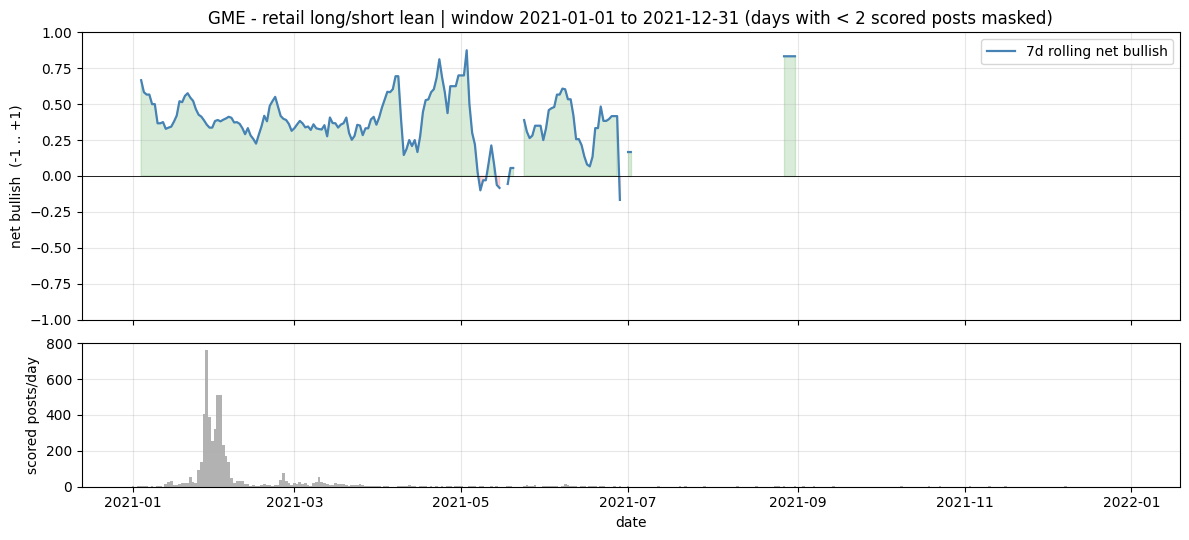

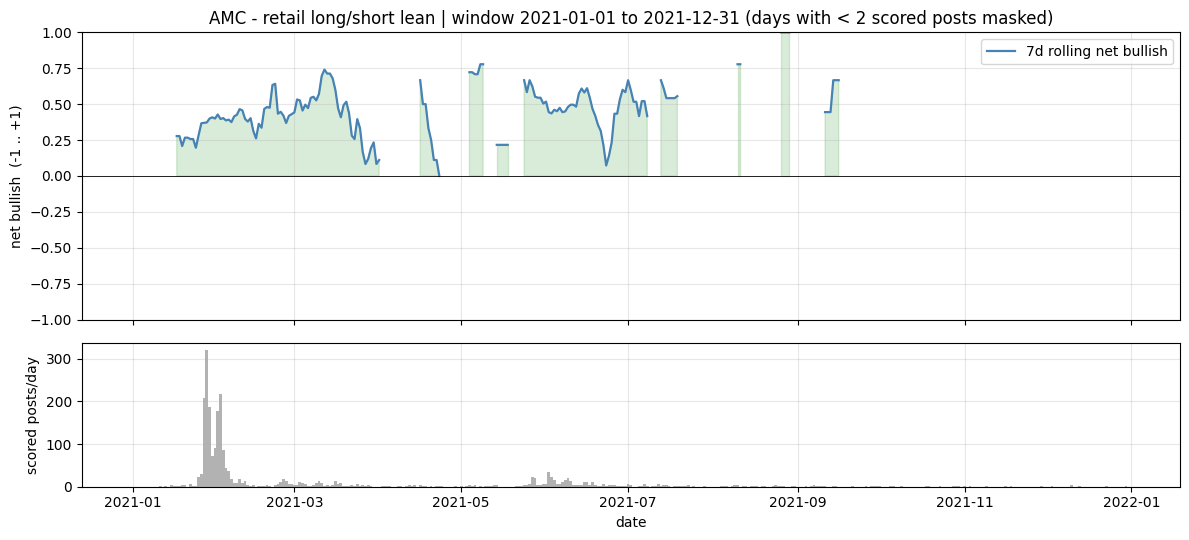

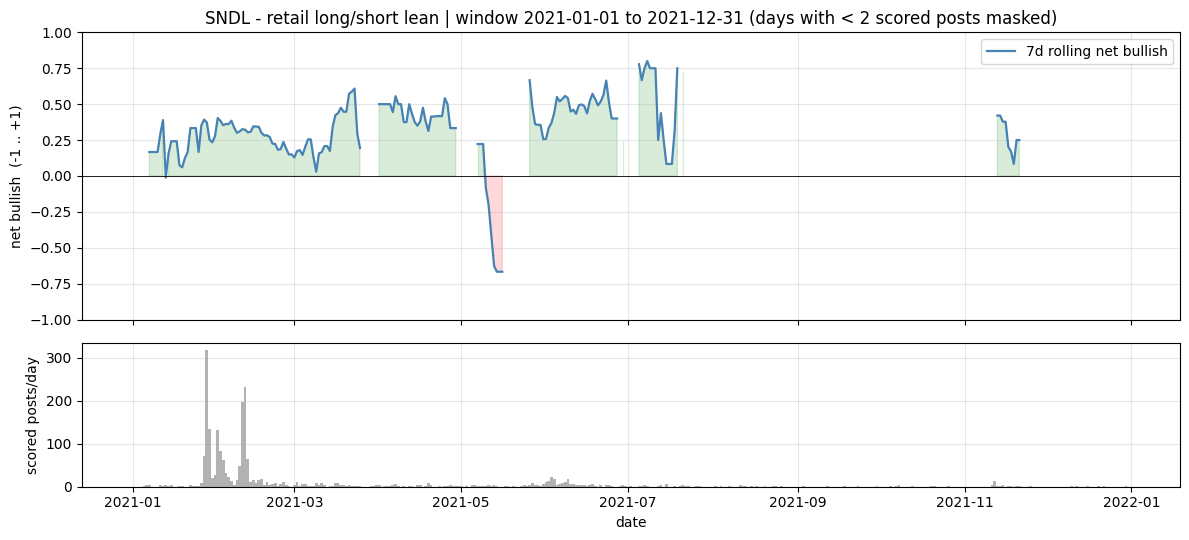

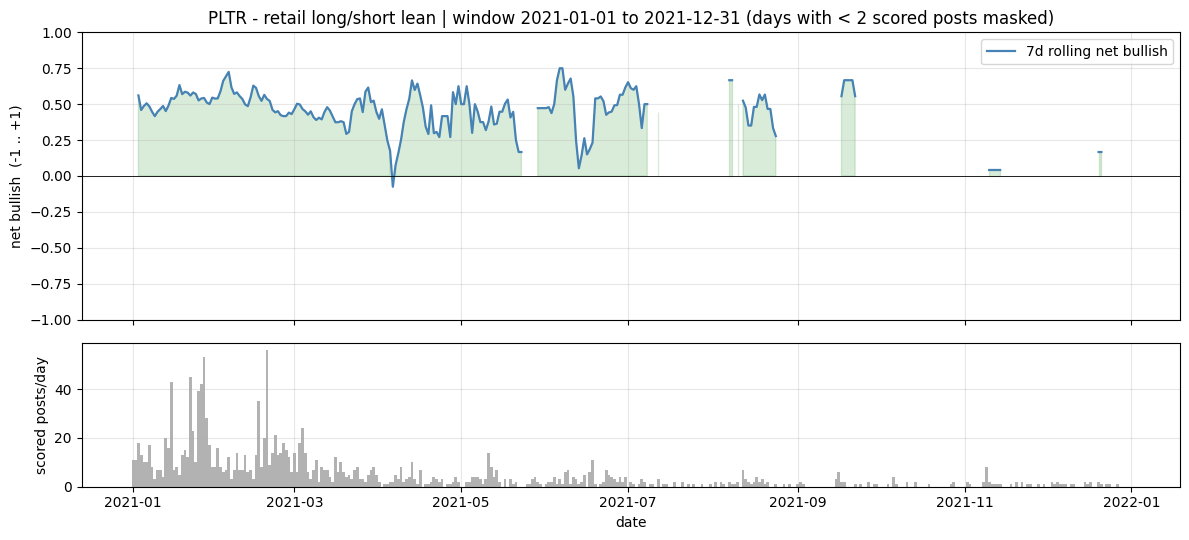

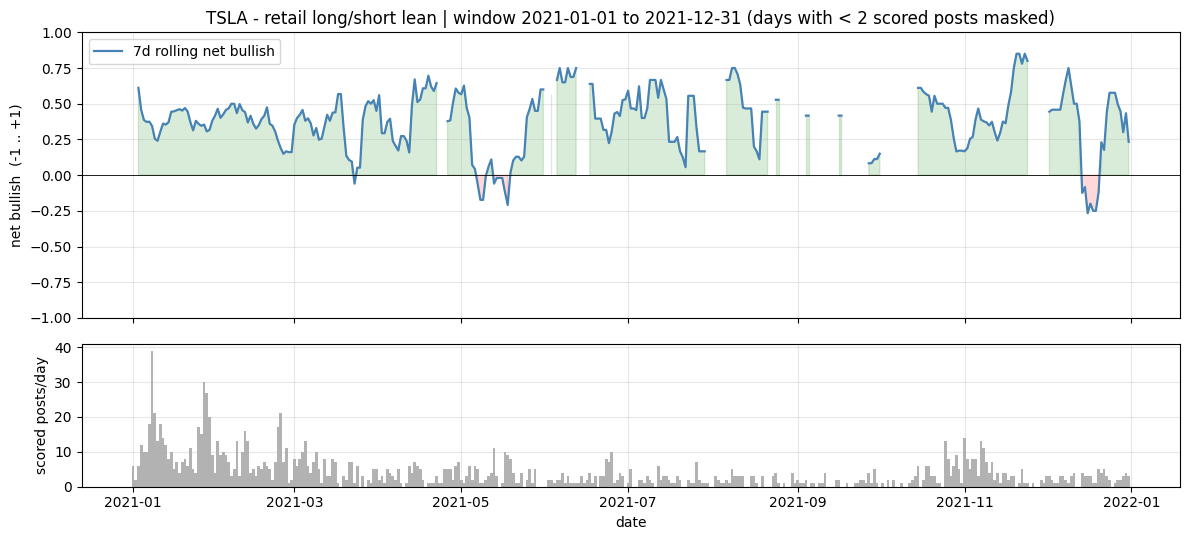

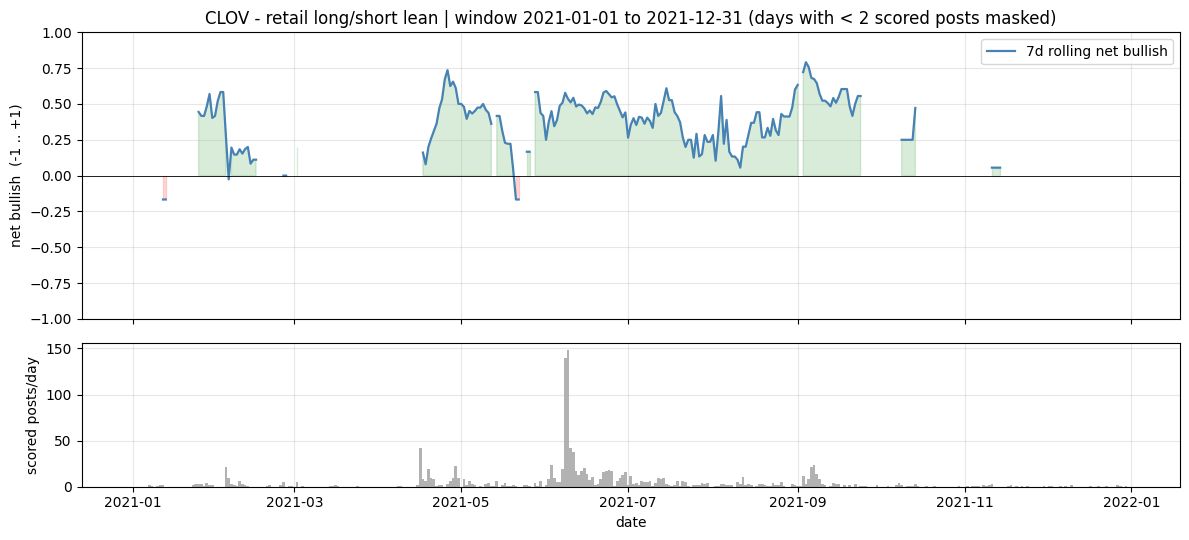

In [18]:
# CHARTS - one per ticker: rolling long/short lean on top, post volume below.
import numpy as np
import matplotlib.pyplot as plt

all_days = pd.date_range(daily_sent['date'].min(), daily_sent['date'].max(), freq='D')

for ticker in chosen:
    one = (daily_sent[daily_sent['ticker'] == ticker]
           .set_index('date').reindex(all_days))
    n = one['n_posts'].fillna(0)
    net = one['net_bullish'].where(n >= MIN_POSTS_EFF)   # mask BEFORE smoothing
    rolled = net.rolling(ROLL, min_periods=max(2, ROLL // 2)).mean()

    fig, (top, bot) = plt.subplots(2, 1, figsize=(12, 5.5), sharex=True,
                                   gridspec_kw={'height_ratios': [2, 1]})
    top.plot(rolled.index, rolled, linewidth=1.6, color='steelblue',
             label=f'{ROLL}d rolling net bullish')
    top.axhline(0, color='black', linewidth=0.6)
    top.fill_between(rolled.index, 0, rolled, where=rolled >= 0, alpha=0.15, color='green')
    top.fill_between(rolled.index, 0, rolled, where=rolled < 0, alpha=0.15, color='red')
    top.set_ylim(-1, 1); top.set_ylabel('net bullish  (-1 .. +1)')
    top.set_title(f'{ticker} - retail long/short lean | window {WINDOW} '
                  f'(days with < {MIN_POSTS_EFF} scored posts masked)')
    top.legend(); top.grid(True, alpha=0.3)

    bot.bar(n.index, n, width=1, color='gray', alpha=0.6)
    bot.set_ylabel('scored posts/day'); bot.set_xlabel('date')
    bot.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

## Momentum map - a snapshot of the LAST 5 DAYS vs the window baseline

Every dot is a ticker (the `MAP_TICKERS` most-posted ones). This is NOT a
full-year picture: it answers "where does the crowd stand RIGHT NOW (the
final 5 days of the window)?", using the rest of the window only as each
ticker's own baseline. The title carries the exact snapshot date.

- **x = mention momentum**: last 5 days' post volume vs the ticker's own
  window baseline (z-score). Right = attention surging.
- **y = sentiment CHANGE** (`sent_delta`): last 5 days' net bullish minus
  the ticker's own window average. Up = the mood is IMPROVING for this
  name. Using the change (not the level) cancels the everything-looks-
  bullish bias that retail forums have.
- **colour** = the absolute 5-day level (green bullish / red bearish),
  **bubble size** = total posts (more crowd = more trustworthy position).

Quadrants: **top-right** = crowding in + mood improving (swarm building);
**bottom-right** = crowding in + mood deteriorating (classic crowded-top /
panic pattern); left half = quiet names.

In [19]:
# Build the monitor stats (one row per ticker).
wide_n = (daily_sent.pivot_table(index='date', columns='ticker', values='n_posts')
          .asfreq('D').fillna(0))
wide_s = (daily_sent.pivot_table(index='date', columns='ticker', values='net_bullish')
          .asfreq('D'))

rows = []
for ticker in wide_n.columns:
    n = wide_n[ticker]
    if n.sum() < MIN_POSTS_EFF * 5:      # too thin to say anything
        continue
    base_std = n.std()
    lookback_z = (n.iloc[-5:].mean() - n.mean()) / base_std if base_std > 0 else 0.0
    log_all = np.log1p(wide_n.iloc[-5:])
    cs = ((log_all[ticker] - log_all.mean(axis=1)) / log_all.std(axis=1)).mean()
    sent_5d = wide_s[ticker].iloc[-5:].mean()
    sent_base = wide_s[ticker].mean()
    rows.append({'ticker': ticker, 'posts_total': int(n.sum()),
                 'lookback_z': float(lookback_z), 'cross_sect_z': float(cs),
                 'sent_5d': None if pd.isna(sent_5d) else float(sent_5d),
                 'sent_delta': None if (pd.isna(sent_5d) or pd.isna(sent_base))
                               else float(sent_5d - sent_base)})

monitor = pd.DataFrame(rows).dropna(subset=['sent_5d', 'sent_delta'])
SNAPSHOT = wide_n.index[-1].date()
print(len(monitor), 'tickers with enough data | snapshot = 5 days ending', SNAPSHOT)

96 tickers with enough data | snapshot = 5 days ending 2021-12-31


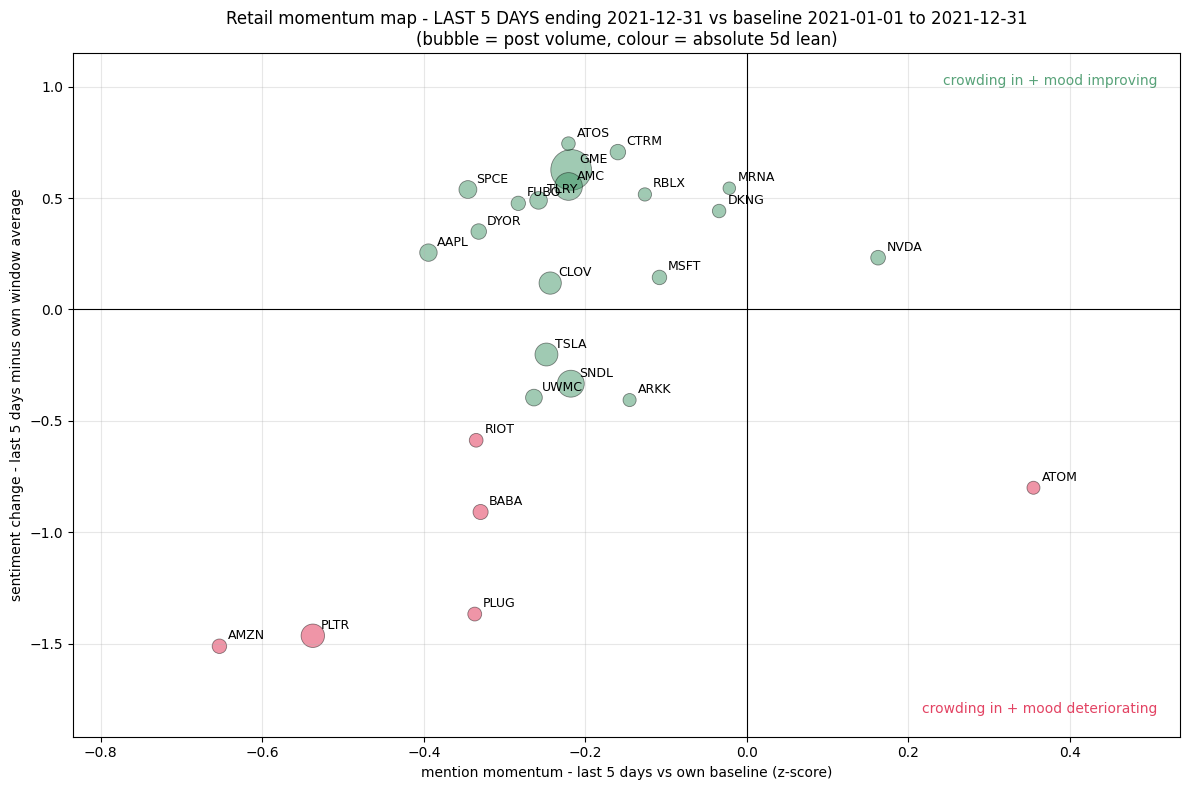

ticker  posts_total  lookback_z  cross_sect_z  sent_5d  sent_delta
  BFRI           14        3.48          5.42     0.00       -0.25
  HIMX           40        2.57          7.48     0.25       -0.49
  RYLD           18        2.40          3.84     1.00        0.29
  SCHD          148        1.63          9.98     0.50       -0.05
    MU           25        1.21          2.31     1.00        0.52
  XERS           24        1.20          2.32     1.00        0.69
  HODL           10        0.96          1.70     1.00        0.22
   SAM           10        0.96          1.47     1.00        0.72
  ORMP           12        0.94          1.47     0.00       -0.33
  ABEV           11        0.91          1.42     0.00       -0.50
  WETH           13        0.89          1.70    -1.00       -1.15
   ZIM           14        0.84          1.57     1.00        0.57
  APAC           13        0.82          1.42     0.00       -0.83
  META           12        0.81          1.42     1.00        

In [20]:
# THE MOMENTUM MAP (change-based y-axis; axes auto-fit so nothing clips).
m = monitor.sort_values('posts_total', ascending=False).head(MAP_TICKERS)

fig, ax = plt.subplots(figsize=(12, 8))
sizes = 60 + 800 * (m['posts_total'] / m['posts_total'].max())
colors = ['seagreen' if s >= 0 else 'crimson' for s in m['sent_5d']]
ax.scatter(m['lookback_z'], m['sent_delta'], s=sizes, c=colors, alpha=0.45,
           edgecolors='black', linewidths=0.6)
for _, r in m.iterrows():
    ax.annotate(r['ticker'], (r['lookback_z'], r['sent_delta']),
                textcoords='offset points', xytext=(6, 5), fontsize=9)

ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.margins(x=0.18, y=0.18)   # auto-fit with headroom - no clipped bubbles
ax.text(0.98, 0.97, 'crowding in + mood improving', transform=ax.transAxes,
        ha='right', va='top', fontsize=10, color='seagreen', alpha=0.8)
ax.text(0.98, 0.03, 'crowding in + mood deteriorating', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=10, color='crimson', alpha=0.8)
ax.set_xlabel('mention momentum - last 5 days vs own baseline (z-score)')
ax.set_ylabel('sentiment change - last 5 days minus own window average')
ax.set_title(f'Retail momentum map - LAST 5 DAYS ending {SNAPSHOT} vs baseline {WINDOW}\n'
             '(bubble = post volume, colour = absolute 5d lean)')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Supporting numbers, risers first.
table = monitor.copy()
for col in ('lookback_z', 'cross_sect_z', 'sent_5d', 'sent_delta'):
    table[col] = table[col].round(2)
print(table.sort_values('lookback_z', ascending=False).head(15).to_string(index=False))